In [1]:
import pandas as pd
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import QuantileTransformer

In [2]:
dat = pd.read_csv('../Data/bird.csv')
dat.head(5)

,id,huml,humw,ulnal,ulnaw,feml,femw,tibl,tibw,tarl,tarw,type
0,0,80.78,6.68,72.01,4.88,41.81,3.70,5.50,4.03,38.70,3.84,SW
1,1,88.91,6.63,80.53,5.59,47.04,4.30,80.22,4.51,41.50,4.01,SW
2,2,79.97,6.37,69.26,5.28,43.07,3.90,75.35,4.04,38.31,3.34,SW
3,3,77.65,5.70,65.76,4.77,40.04,3.52,69.17,3.40,35.78,3.41,SW
4,4,62.80,4.84,52.09,3.73,33.95,2.72,56.27,2.96,31.88,3.13,SW


In [3]:
dat = dat.iloc[:, 1:]
dat.head(5)

,huml,humw,ulnal,ulnaw,feml,femw,tibl,tibw,tarl,tarw,type
0,80.78,6.68,72.01,4.88,41.81,3.70,5.50,4.03,38.70,3.84,SW
1,88.91,6.63,80.53,5.59,47.04,4.30,80.22,4.51,41.50,4.01,SW
2,79.97,6.37,69.26,5.28,43.07,3.90,75.35,4.04,38.31,3.34,SW
3,77.65,5.70,65.76,4.77,40.04,3.52,69.17,3.40,35.78,3.41,SW
4,62.80,4.84,52.09,3.73,33.95,2.72,56.27,2.96,31.88,3.13,SW


In [4]:
dat.describe().T

,count,mean,std,min,25%,50%,75%,max
huml,419.0,64.650501,53.834549,9.85,25.1700,44.180,90.310,420.00
humw,419.0,4.370573,2.854617,1.14,2.1900,3.500,5.810,17.84
ulnal,417.0,69.115372,58.784775,14.09,28.0500,43.710,97.520,422.00
ulnaw,418.0,3.597249,2.186747,1.00,1.8700,2.945,4.770,12.00
feml,418.0,36.872416,19.979082,11.83,21.2975,31.130,47.120,117.07
femw,419.0,3.220883,2.023581,0.93,1.7150,2.520,4.135,11.64
tibl,418.0,64.662823,37.838145,5.50,36.4175,52.120,82.870,240.00
tibw,419.0,3.182339,2.080827,0.87,1.5650,2.490,4.255,11.03
tarl,419.0,39.229976,23.184313,7.77,23.0350,31.740,50.250,175.00
tarw,419.0,2.930024,2.185673,0.66,1.4250,2.230,3.500,14.09


In [5]:
dat.isna().sum()

huml     1
humw     1
ulnal    3
ulnaw    2
feml     2
femw     1
tibl     2
tibw     1
tarl     1
tarw     1
type     0
dtype: int64

In [6]:
dat.dropna(axis=0, inplace=True)

In [7]:
dat.duplicated().sum()

np.int64(0)

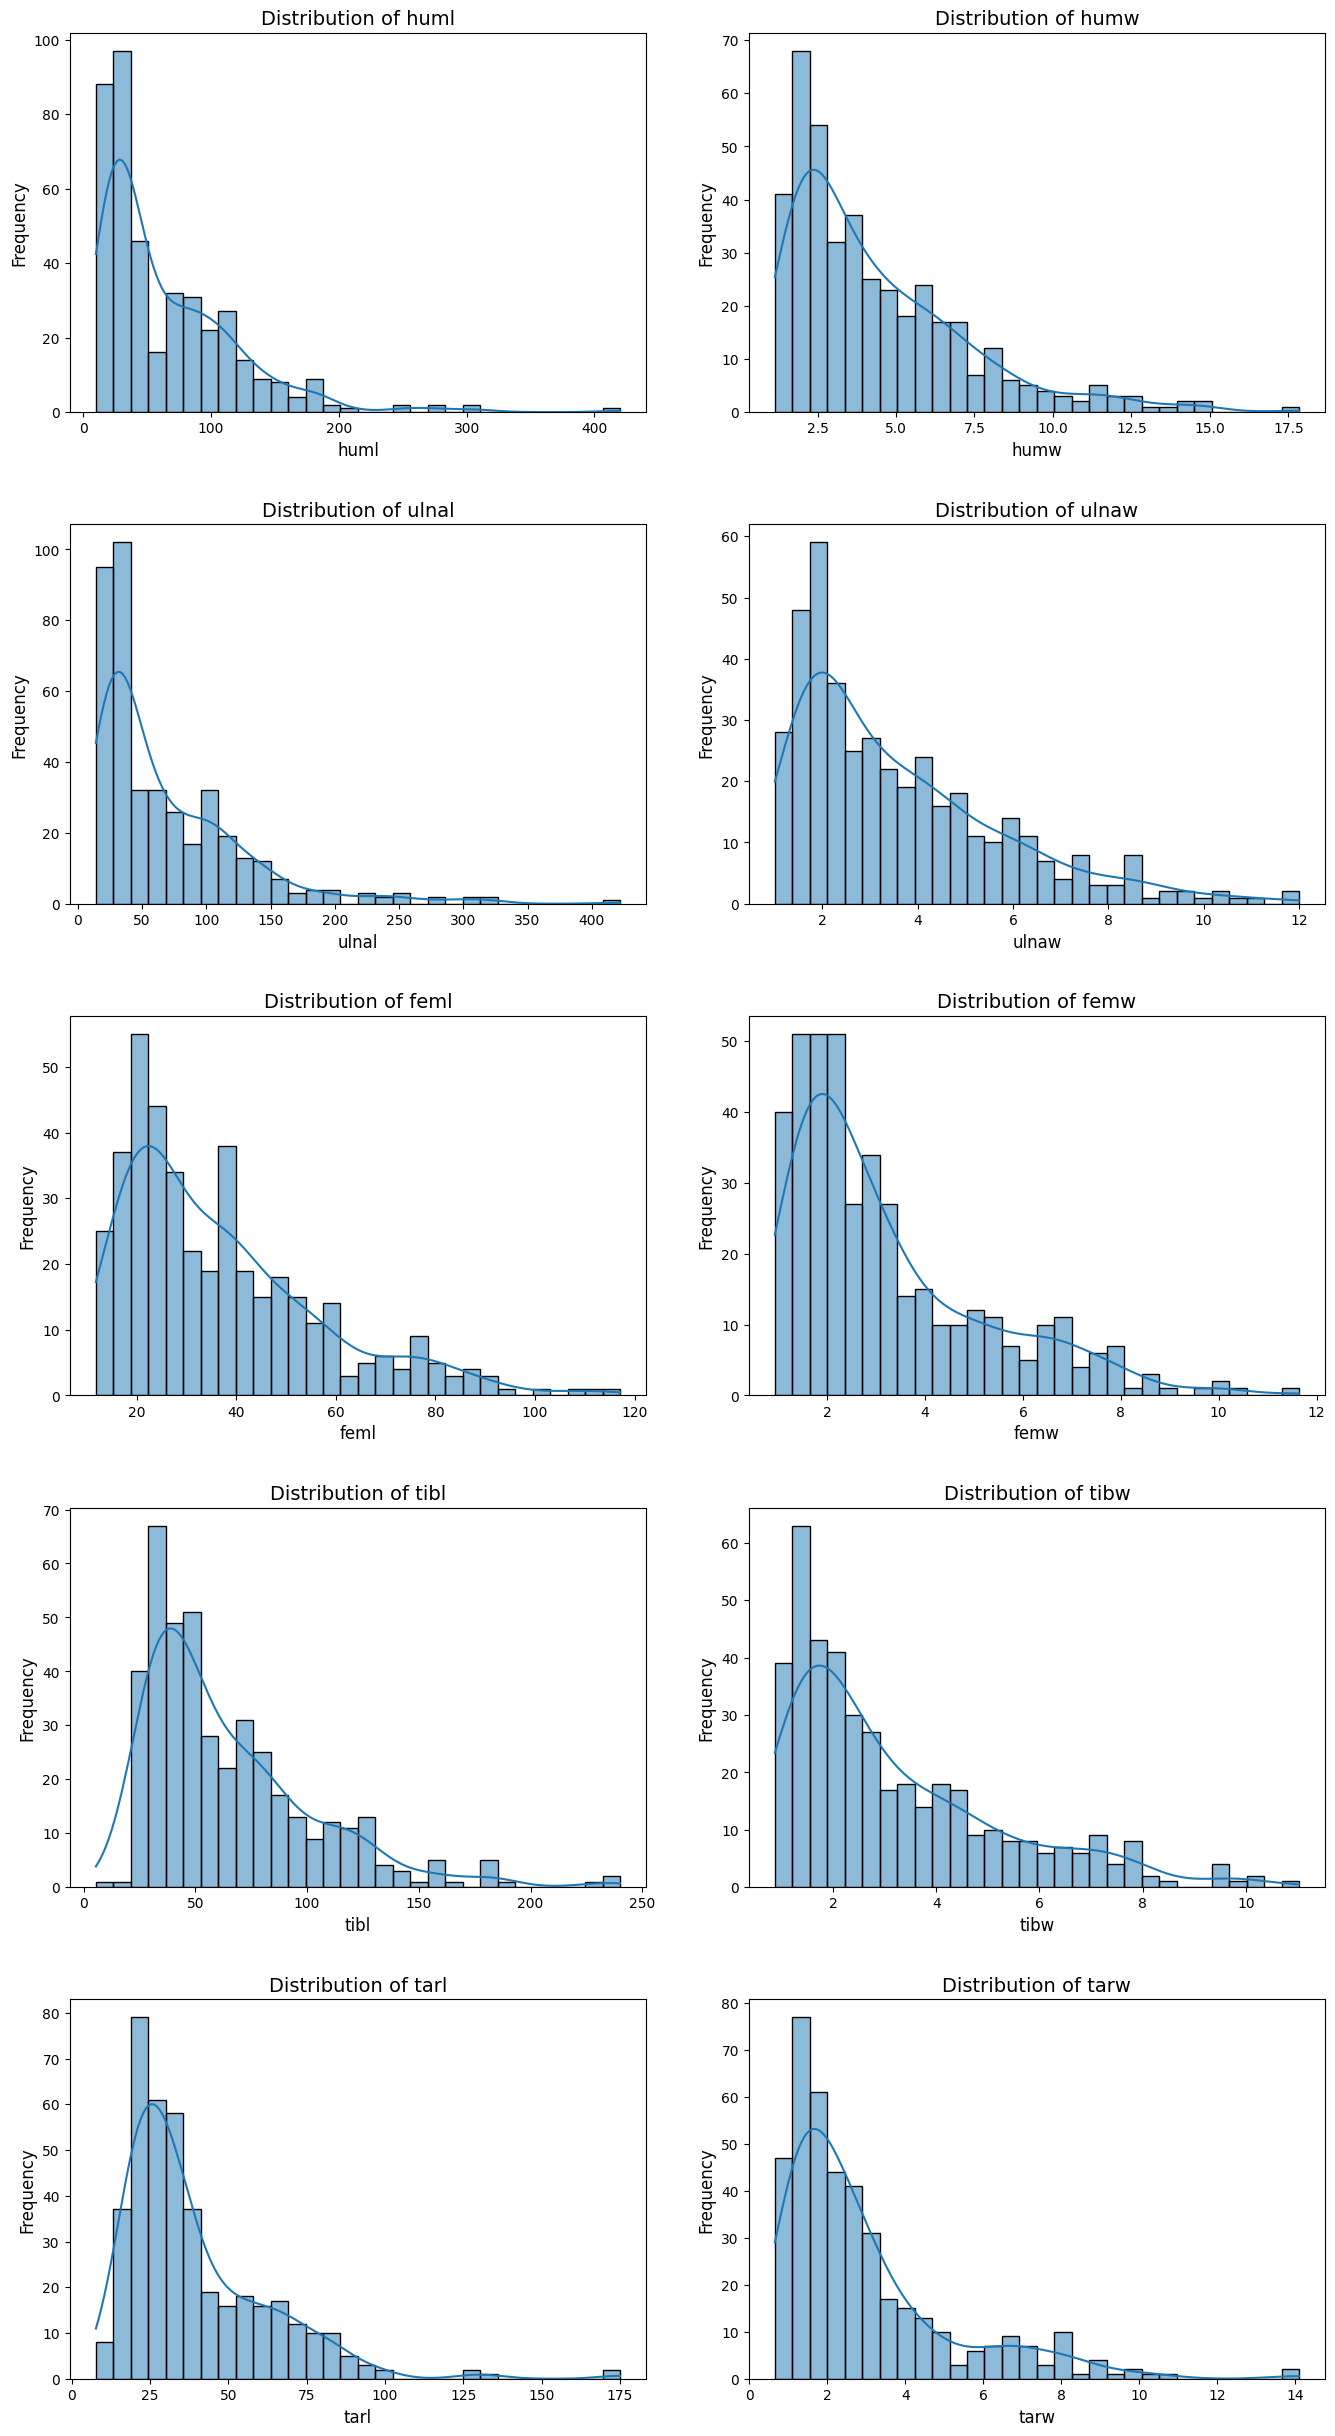

In [8]:
feats = dat.columns[:-1]
nfeats = len(feats)

ncols = 2
nrows = (nfeats + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 5 * nrows))
axes = axes.flatten()

for i, feat in enumerate(feats):
    ax = axes[i]
    sns.histplot(data=dat, x=feat, bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feat}', fontsize=14)
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)

for i in range(nfeats, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0)

plt.show()

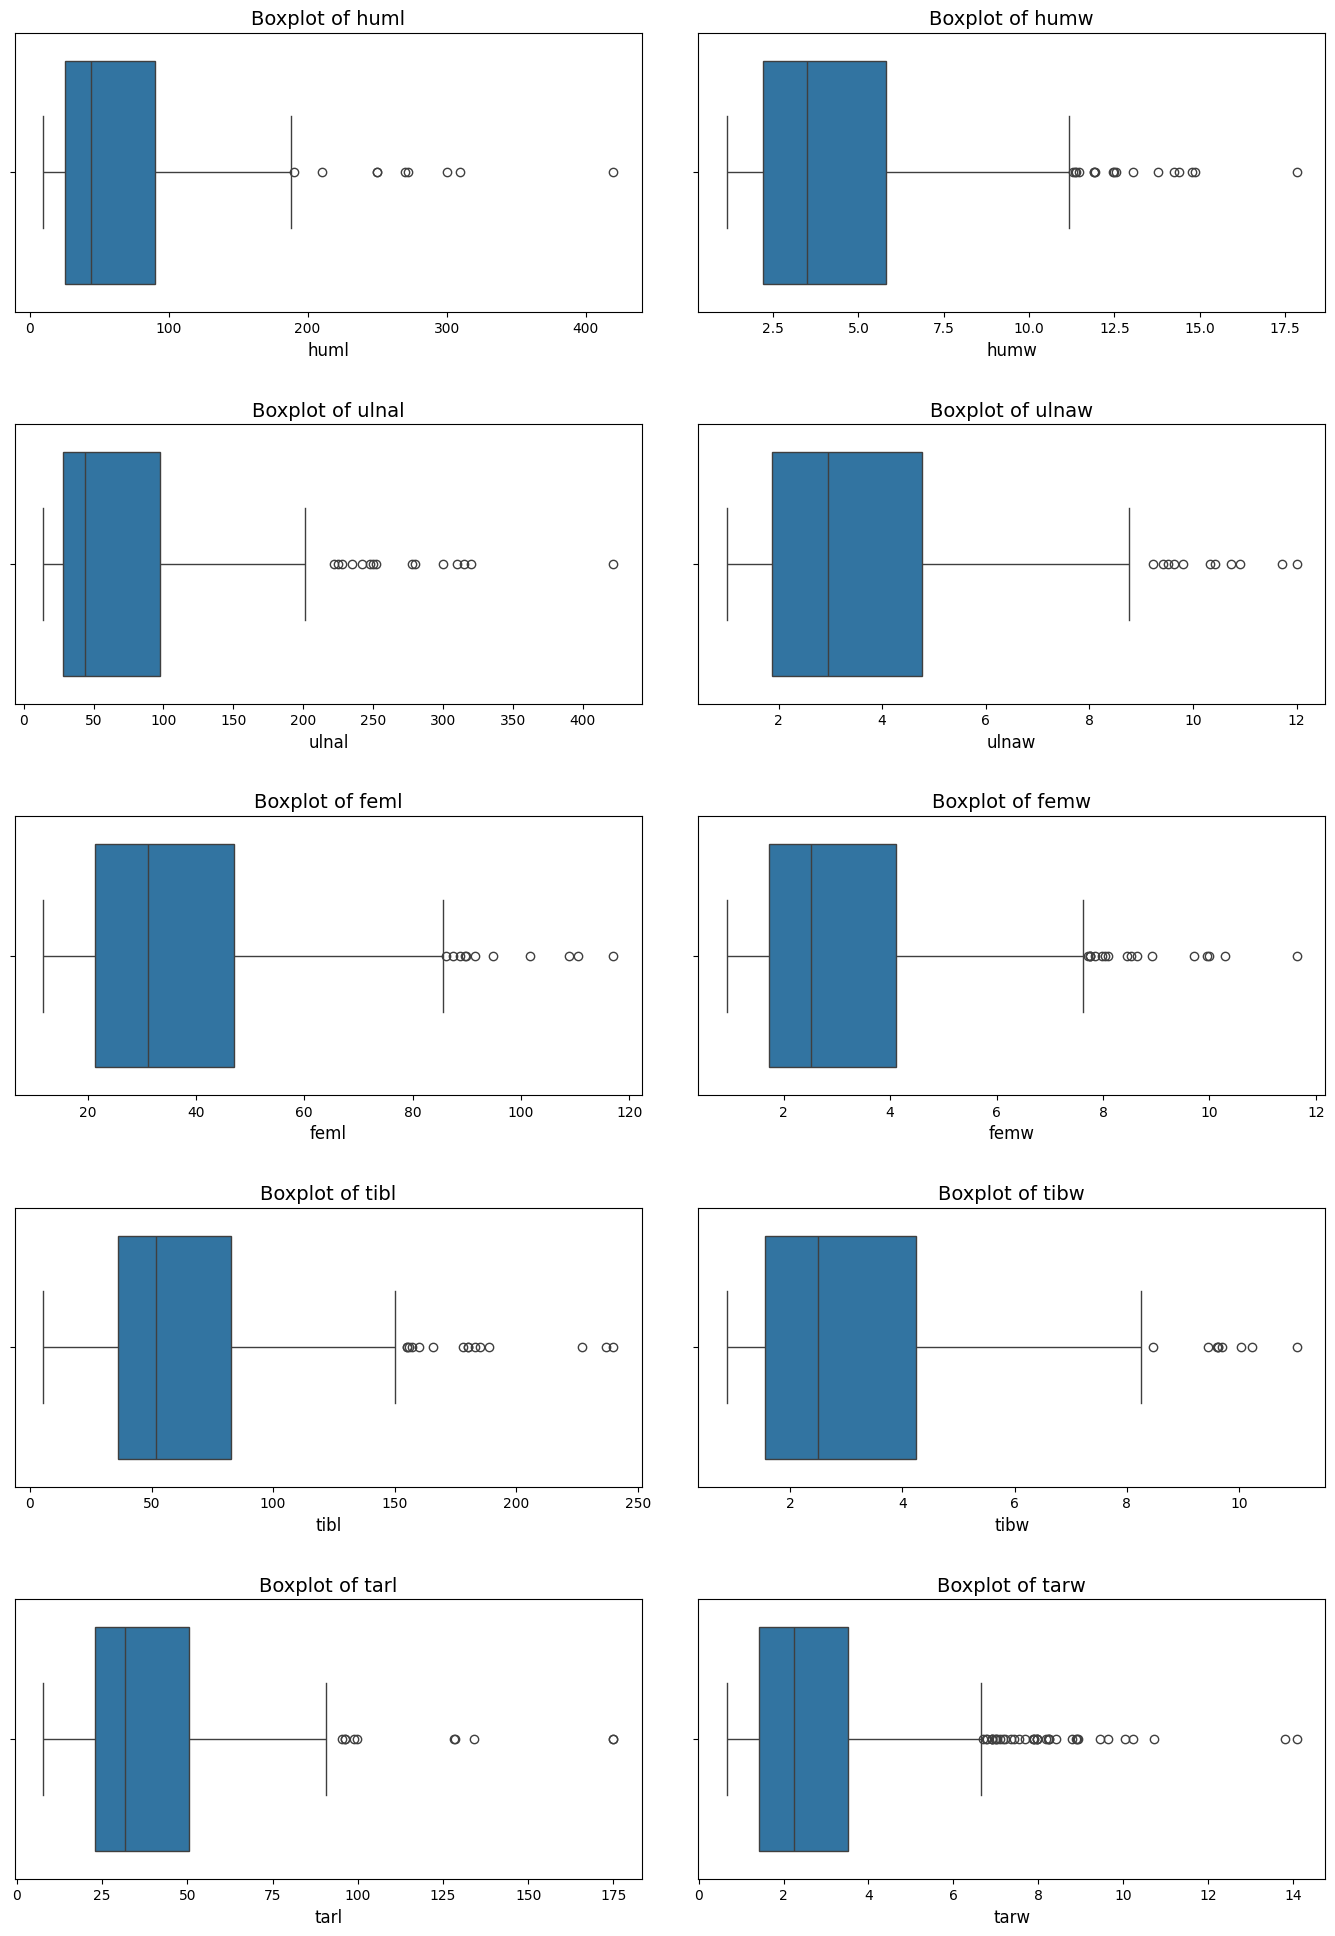

In [9]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for i, feat in enumerate(feats):
    ax = axes[i]
    sns.boxplot(data=dat, x=feat, ax=ax)
    ax.set_title(f'Boxplot of {feat}', fontsize=14)
    ax.set_xlabel(feat, fontsize=12)

for i in range(nfeats, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0)

plt.show()

In [10]:
for col in dat.columns[:-1]:
	percentile_9x = dat[col].quantile(0.95)
	dat[col] = np.where(dat[col] > percentile_9x, percentile_9x, dat[col])

In [11]:
dat.select_dtypes(exclude=['object']).kurt()

huml    -0.268146
humw    -0.020570
ulnal    0.216083
ulnaw   -0.187141
feml    -0.179621
femw    -0.155465
tibl    -0.469206
tibw    -0.226353
tarl    -0.251484
tarw     0.706432
dtype: float64

In [12]:
qt = QuantileTransformer(output_distribution='normal', n_quantiles=dat.shape[1])

tmp = pd.DataFrame(qt.fit_transform(dat.select_dtypes(exclude=['object'])), columns=dat.select_dtypes(exclude=['object']).columns, index=dat.select_dtypes(exclude=['object']).index)
dat[['huml', 'humw', 'ulnal', 'ulnaw', 'feml', 'femw', 'tibl', 'tibw', 'tarl', 'tarw']] = tmp
del tmp
print(dat.select_dtypes(exclude=['object']).kurt())
dat

huml     5.070787
humw     4.832370
ulnal    4.999975
ulnaw    4.807185
feml     4.663816
femw     4.892134
tibl     5.072770
tibw     4.642497
tarl     4.973547
tarw     4.957892
dtype: float64


,huml,humw,ulnal,ulnaw,feml,femw,tibl,tibw,tarl,tarw,type
0,0.493132,0.905669,0.366335,0.696954,0.498605,0.541367,-5.199338,0.607517,0.336817,0.739044,SW
1,0.614002,0.895225,0.476943,0.919910,0.671412,0.689712,0.617225,0.782078,0.430910,0.796144,SW
2,0.480455,0.842415,0.331633,0.835038,0.549087,0.589348,0.522407,0.610954,0.323963,0.583316,SW
3,0.444558,0.646300,0.288031,0.661302,0.394189,0.473130,0.366274,0.390097,0.232225,0.604203,SW
4,0.229155,0.407537,0.109428,0.290183,0.111411,0.098458,0.087543,0.237847,0.007976,0.519490,SW
...,...,...,...,...,...,...,...,...,...,...,...
415,-1.374307,-1.388506,-1.572878,-1.497950,-1.110173,-0.903156,-1.072888,-1.017131,-0.808331,-1.072501,SO
416,-1.294630,-1.377524,-1.440880,-1.283871,-0.986960,-1.023566,-0.927876,-1.129740,-0.624286,-1.072501,SO
417,-1.320471,-1.388506,-1.519021,-1.207244,-0.764833,-1.052397,-0.845463,-0.859801,-0.705894,-0.950718,SO
418,-1.140543,-1.198114,-1.312586,-1.265323,-0.711692,-0.981848,-0.686157,-0.727249,-0.396492,-0.894838,SO


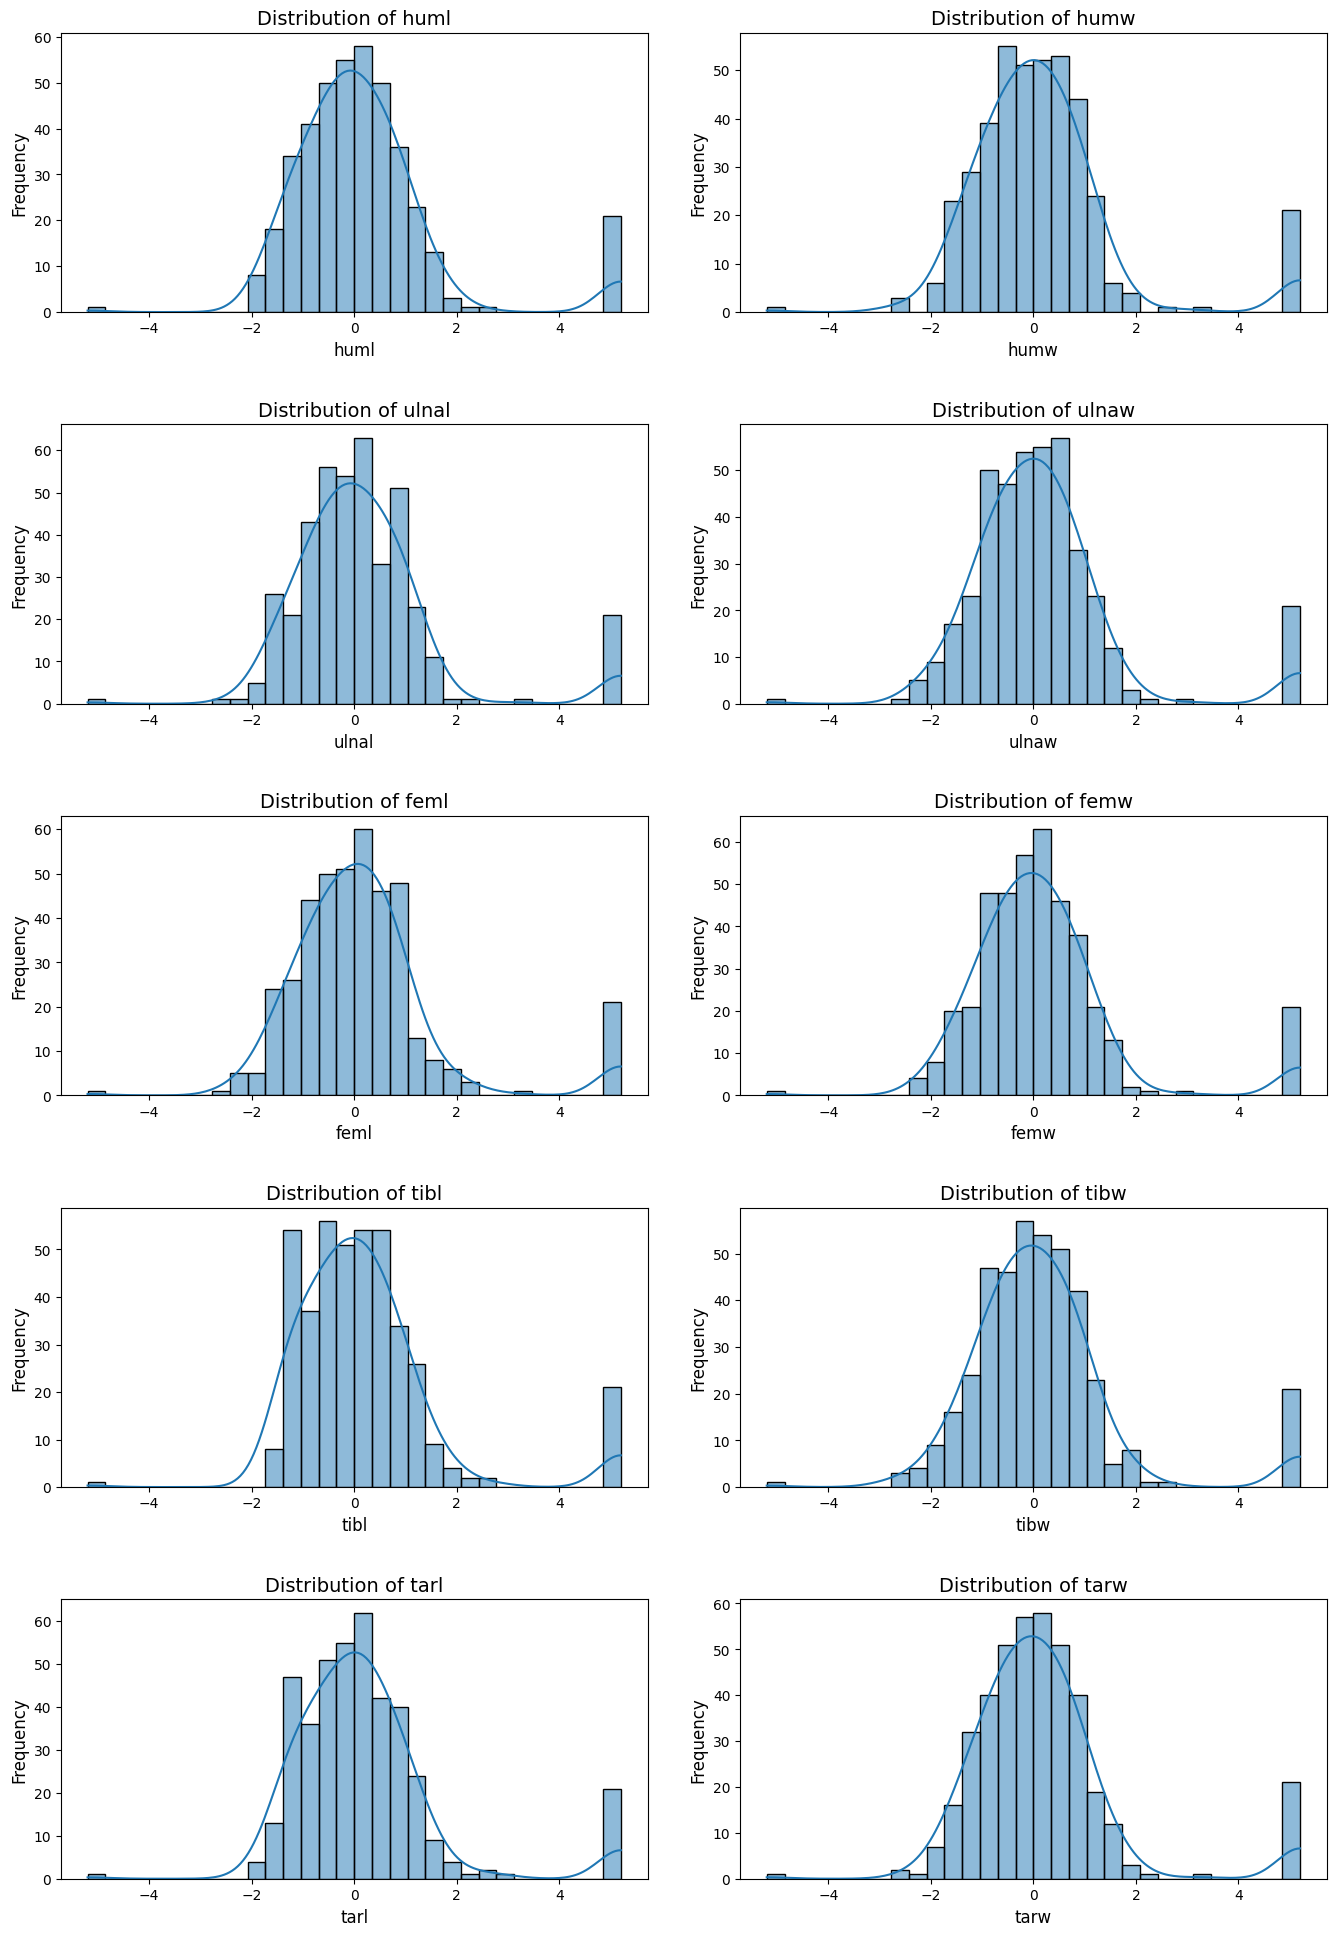

In [13]:
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4 * nrows))
axes = axes.flatten()
for i, feat in enumerate(feats):
    ax = axes[i]
    sns.histplot(data=dat, x=feat, bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {feat}', fontsize=14)
    ax.set_xlabel(feat, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)

for i in range(nfeats, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(pad=3.0)

plt.show()

In [14]:
X = dat.iloc[:, :-1]
y = dat.iloc[:, -1]

In [15]:
LE = LabelEncoder()
y_enc = LE.fit_transform(y)
y_cat = keras.utils.to_categorical(y_enc)

In [16]:
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)

In [17]:
smote = SMOTE(random_state=42)
X_resamp, y_resamp_enc = smote.fit_resample(X_scaled, y_enc)
y_resamp_cat = keras.utils.to_categorical(y_resamp_enc)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resamp, y_resamp_cat, train_size=0.8, random_state=40
)

In [19]:
model = keras.Sequential([
	keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(120, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(60, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(30, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(y_train.shape[1], activation='softmax')
])

In [20]:
model.compile(
	optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 120)            │         1,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 60)             │         7,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 30)             │         1,830 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           186 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,596 (41.39 KB)

 Trainable params: 10,596 (41.39 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.fit(X_train, y_train, epochs=102, batch_size=32, validation_split=0.2, verbose=2)

Epoch 1/102
15/15 - 2s - 111ms/step - accuracy: 0.1891 - loss: 1.7925 - val_accuracy: 0.3277 - val_loss: 1.7399
Epoch 2/102
15/15 - 0s - 11ms/step - accuracy: 0.3046 - loss: 1.7195 - val_accuracy: 0.3866 - val_loss: 1.6891
Epoch 3/102
15/15 - 0s - 11ms/step - accuracy: 0.3298 - loss: 1.6792 - val_accuracy: 0.4454 - val_loss: 1.6391
Epoch 4/102
15/15 - 0s - 9ms/step - accuracy: 0.3950 - loss: 1.6249 - val_accuracy: 0.5882 - val_loss: 1.5434
Epoch 5/102
15/15 - 0s - 14ms/step - accuracy: 0.4433 - loss: 1.5427 - val_accuracy: 0.5714 - val_loss: 1.4347
Epoch 6/102
15/15 - 0s - 12ms/step - accuracy: 0.4706 - loss: 1.4700 - val_accuracy: 0.5966 - val_loss: 1.3365
Epoch 7/102
15/15 - 0s - 11ms/step - accuracy: 0.5042 - loss: 1.4110 - val_accuracy: 0.6218 - val_loss: 1.2711
Epoch 8/102
15/15 - 0s - 10ms/step - accuracy: 0.5441 - loss: 1.3573 - val_accuracy: 0.5882 - val_loss: 1.2245
Epoch 9/102
15/15 - 0s - 11ms/step - accuracy: 0.5588 - loss: 1.2889 - val_accuracy: 0.6471 - val_loss: 1.1330
E

In [22]:
loss, acc = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {acc*100:.3f}%')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9475 - loss: 0.3003 
Test Accuracy: 95.973%


In [23]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_test_labs = np.argmax(y_test, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


In [24]:
print('Classification Report :')
print(classification_report(y_test_labs, y_pred, target_names=LE.classes_))

Classification Report :
              precision    recall  f1-score   support

           P       1.00      0.96      0.98        25
           R       0.97      1.00      0.98        29
          SO       1.00      1.00      1.00        27
          SW       0.87      0.81      0.84        16
           T       0.96      1.00      0.98        23
           W       0.93      0.93      0.93        29

    accuracy                           0.96       149
   macro avg       0.95      0.95      0.95       149
weighted avg       0.96      0.96      0.96       149



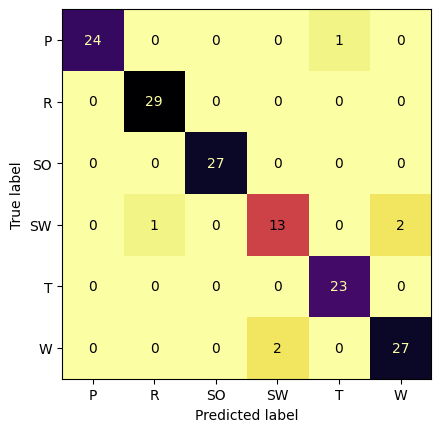

In [25]:
cm = confusion_matrix(y_test_labs, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(LE.classes_)).plot(cmap='inferno_r', colorbar=False)
plt.show()

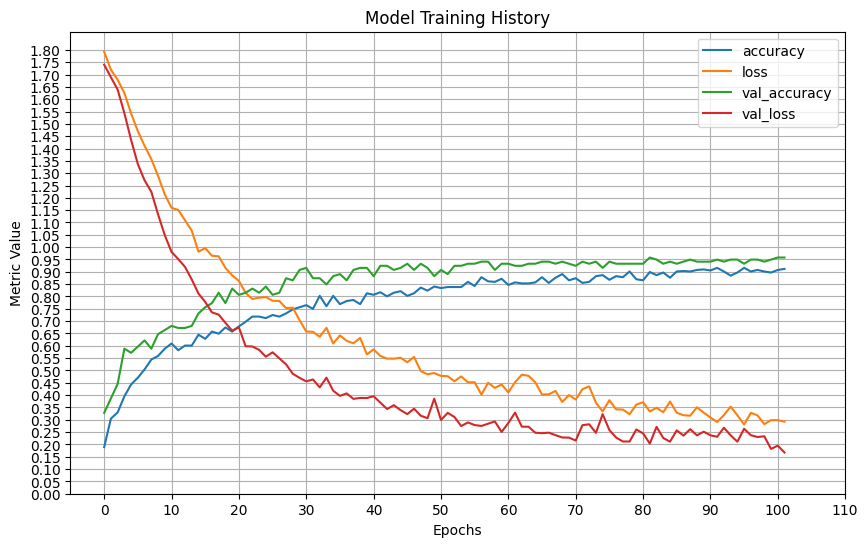

In [26]:
pd.DataFrame(model.history.history).plot(figsize=(10, 6))
plt.grid(True)
plt.title('Model Training History')
plt.xlabel('Epochs')
plt.ylabel('Metric Value')
plt.xticks(np.arange(0, model.history.epoch[-1]+10, 10))
plt.yticks(np.arange(0, max(max(model.history.history['loss']),max(model.history.history['val_loss']))+0.05, 0.05))
plt.show()